# PROC MODECLUSによる系統監視地点の密度ベースクラスタリング

## エグゼクティブサマリー

ある配電事業者は、PROC MODECLUSを用いて、地図座標のみから系統監視地点(変電所や
フィーダーセンサー)の間にあるノンパラメトリックな密度ベースのクラスタを見つけ出す。
MODECLUSは地点上の密度曲面を推定し、低密度のギャップで隔てられた高密度領域を
クラスタとみなす。3kmの一様カーネル半径で90の合成地点に対して実行すると、
データに組み込んだ3つの高密度サービス地区が、上位3つの最大クラスタ(24、24、21地点)
として回収される。一方、散在する農村部の地点は疎な領域に落ち、独自の1地点・2地点の
小規模クラスタに分かれる。この孤立地点の集合が業務上の成果物であり、資本計画チーム
向けの遠隔資産候補リストとなる。

## データソース

| データセット | 行数 | 説明 |
|---------|------|-------------|
| `grid_sites` | 90 | `call streaminit(70531)` と `rand()` を用いてインラインで生成した合成の配電監視地点。3つの高密度サービス地区(UrbanCore、Suburban、Industrial)は、それぞれ異なる地図重心を中心とした二変量正規分布から抽出され、加えて22の散在する農村(Rural)地点が領域全体から一様に抽出される。 |

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `site_id` | 数値 | 一意の監視地点識別子(1~90)。 |
| `region` | 文字 | 各地点がどのように生成されたかを記録する計画用ラベル(UrbanCore、Suburban、Industrial、Rural)。クラスタリングからは除外する。 |
| `x_km`, `y_km` | 数値 | 事業者の計画グリッド上の地点位置(km単位)。クラスタリングに用いる変数。 |
| `peak_load_mw` | 数値 | 当該地点で観測された年間ピーク負荷(MW)。後続の解釈のために保持する。 |

# 系統監視地点の密度ベースクラスタリング

ある地域配電事業者は、サービス territory 全体に広がる**監視地点**
(変電所やフィーダーセンサー)のネットワークを運用している。プランナーは、
グループ数を事前に指定することなく、純粋に地理的な位置に基づいてこれらの地点を
自然な**サービス地区**にグループ化したいと考えており、また、密集した地区に
属さない**孤立した農村資産**を特定したいと考えている。

`PROC MODECLUS`はこれに適している: *ノンパラメトリックな密度ベース*クラスタリングを
行うためである。地点上の密度関数を推定し、低密度のギャップで隔てられた高密度地点領域を
クラスタとみなす。疎な外れ値は地区に吸収されるのではなく、独自の小さなクラスタに
分かれる -- これはまさに、遠隔地点を検出するために望む挙動である。

本ノートブックは以下を行う:
1. 90地点からなる現実的な合成地点ネットワークを生成する。
2. **一様カーネル**で地点密度を推定し、平滑化半径`R=`を走査して、回収された地区が
   安定していることを確認する。
3. 作業用の半径を固定し、各地点の密度とクラスタラベルを持つ`OUT=`データセットを
   書き出し、結果を地図化する。

## ステップ1 -- 合成監視地点ネットワークの生成

90地点をシミュレートする。3つの高密度**サービス地区**は、それぞれ異なる地図重心
(UrbanCoreは(12, 30)付近、Suburbanは(30, 15)付近、Industrialは(20, 42)付近)を
中心とした二変量正規分布から抽出され、24、24、20地点のコンパクトな高密度の塊りを
形成する。4番目の集合として、22の**Rural(農村)**地点が領域全体から一様に抽出され、
事業者が孤立とみなすであろう疎な散在地点を生み出す。

`region`ラベルは各地点がどのように生成されたかを記録するが、MODECLUSが座標のみから
構造を再発見できるよう、意図的にクラスタリングからは**除外する**。`peak_load_mw`は
後の解釈のために保持する。

In [1]:
データ grid_sites;
   呼出 streaminit(70531);
   長さ region $ 18;

   /* 高密度都市中心部の地区 */
   繰返 site_id = 1 から 24;
      region = '都市中心部';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      出力;
   終了;

   /* 郊外の地区 */
   繰返 site_id = 25 から 48;
      region = '郊外';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      出力;
   終了;

   /* 工業地区(ピーク負荷がより高い) */
   繰返 site_id = 49 から 68;
      region = '工業地区';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      出力;
   終了;

   /* 分散した農村部の地点(疎、低負荷) */
   繰返 site_id = 69 から 90;
      region = '農村部';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      出力;
   終了;
実行;

表題 '合成系統監視地点';
処理 MEANS データ=grid_sites n mean std MIN MAX maxdec=2;
   分類 region;
   変数 x_km y_km peak_load_mw;
   見出 region='地域';
実行;

                                                        合成系統監視地点                                                        

                                                  The MEANS Procedure

                                                Analysis Variable : x_km

        地域                       N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------
        工業地区                        20          20.36           0.96          18.52          21.53
        農村部                         22          29.79          10.62          11.06          47.45
        郊外                          24          29.96           1.73          26.51          33.60
        都市中心部                       24          12.07           1.34           8.65          14.42
        ------------------------------------------------------------------------------------------

                                       


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 合成系統監視地点.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


平均値は、3つのタイトな地区と1つの拡散したグループを裏付けている。3つの高密度地域は
座標の標準偏差が小さく(各軸でおよそ1~1.7km)、はっきりと分かれた重心を持つ一方、
農村部グループはグリッド全体に広がっている(両軸とも標準偏差10kmを超える)。ピーク負荷も
各地区を分けている -- 工業地区は平均約6MW、都市中心部は約4.6MW、郊外は約2.7MW、
農村部は約1.5MW -- これは地理的クラスタが得られた後に役立つ文脈情報である。

## ステップ2 -- 一様カーネル密度クラスタリングと半径スキャン

一様カーネル密度推定は**半径`R=`**を用いる: `R`キロメートル以内にあるすべての地点が
その地点の局所密度に寄与する。`R`が小さいと密度がでこぼこになり領域が断片化し、
`R`が大きいと過剰に平滑化されて地区が併合されてしまう。SASの専門家は単一の値を
決して信用しない -- 半径の範囲を走査し、密集地区が持続する一方で散在する単独地点の
数だけが変動する、**安定した**クラスタ数を探す。

ここでは`M=1`によりクラスタリング手法1(標準的なノンパラメトリック手法)を選択し、
`R=2.5 to 4 by 0.5`という半径を一度の呼び出しで要求する。MODECLUSは半径ごとに
1回解析を実行し、それぞれのクラスタ数を報告する。`SHORT`は詳細な
クラスタ別統計量の出力を抑制する。

In [2]:
表題 'グリッド地点の一様カーネル密度クラスタリング';
title2 '半径スキャン R = 2.5 ~ 4.0 km';

処理 modeclus データ=grid_sites m=1 r=2.5 to 4 by 0.5 short;
   変数 x_km y_km;
   id site_id;
実行;

                                                 グリッド地点の一様カーネル密度クラスタリング                                                 
                                                半径スキャン R = 2.5 ~ 4.0 km                                                 


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to グリッド地点の一様カーネル密度クラスタリング.
NOTE: Option TITLE2 changed to 半径スキャン R = 2.5 ~ 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


クラスタ数はスキャンを通じて緩やかにしか変化しない -- `R=2.5`で23クラスタ、
`R=3.0`で22、`R=3.5`で19、`R=4.0`で18である。この高い生の数は散在する農村部の
地点に由来する: 孤立した各地点はそれぞれ疎な近傍に位置し、1地点クラスタを形成するため、
18~23の「クラスタ」の大半は単独地点である。その根底で一定に保たれているのは、
重要な構造である -- 3つの高密度地区は、どの半径でも大きく明確に分離された
3クラスタのまま残る。`R`が広がるにつれて、散在する単独地点のいくつかが隣接地点や
近くの地区と併合するため、総数は激しく振れるのではなくゆっくりと減少していく。
その安定性こそが、3地区解が単一の帯域幅のアーティファクトではなく、実在するもので
あることを示す信号である。

## ステップ3 -- 地図化のための最終クラスタ解

3つの地区がスキャン全体で安定していることを確認したので、単一の作業用半径
(`R=3` km)を固定し、完全なクラスタ別表示のための**ALL**オプションと、
結果を地図化できるよう元の座標に`DENSITY`推定値と`CLUSTER`割り当てを
書き出す**OUT=**を要求する。クラスタはモード密度の降順に番号付けされるため、
最も密度の高い地区がクラスタ1、2、3となり、疎な地点はより大きい番号を取る。

In [3]:
表題 '最終的な密度ベースクラスタ解';
title2 '一様カーネル、R = 3 km';

処理 modeclus データ=grid_sites m=1 r=3 out=join_out ALL;
   変数 x_km y_km;
   id site_id;
実行;

                                                     最終的な密度ベースクラスタ解                                                     
                                                    一様カーネル、R = 3 km                                                     


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to 最終的な密度ベースクラスタ解.
NOTE: Option TITLE2 changed to 一様カーネル、R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


クラスタサマリーはこの構造を明示している。`R=3`の解は**22クラスタ**を返すが、
密度によって明確に階層化されている:

- **クラスタ1** -- 24地点、モード密度約0.0090(UrbanCore=都市中心部の地区)。
- **クラスタ2** -- 24地点、モード密度約0.0079(Suburban=郊外の地区)。
- **クラスタ3** -- 21地点、モード密度約0.0079(Industrial=工業地区。たまたま
  その端に位置していた農村部の地点を1つ取り込んでいる)。
- **クラスタ4~22** -- 3地点のグループ1つと、18の単独地点クラスタ。いずれも
  モード密度は約0.0004で、地区よりおよそ20倍疎である。

3つの高密度地区で90地点中69地点を占め、残る21地点が散在する農村部の資産であり、
それぞれが低密度の近傍にほぼ単独で位置している。地区と孤立地点を分けるのは、
あらかじめ決めたクラスタ数ではなく密度である。

## ステップ4 -- クラスタの地図化

各地点が3つの高密度地区のいずれかに属する(`cluster <= 3`)か、疎な小規模クラスタに
属するかをタグ付けし、その状態で色分けしてすべての地点を地図座標上にプロットする。
これはプランナーの視点である: 高密度地区はサービス地域として管理し、孤立地点は
個別対応のためにフラグを立てる。

                                                    回収されたサービス地区と孤立地点                                                    
                                                一様カーネル密度クラスタリング、R = 3 km                                                




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to 回収されたサービス地区と孤立地点.
NOTE: Option TITLE2 changed to 一様カーネル密度クラスタリング、R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


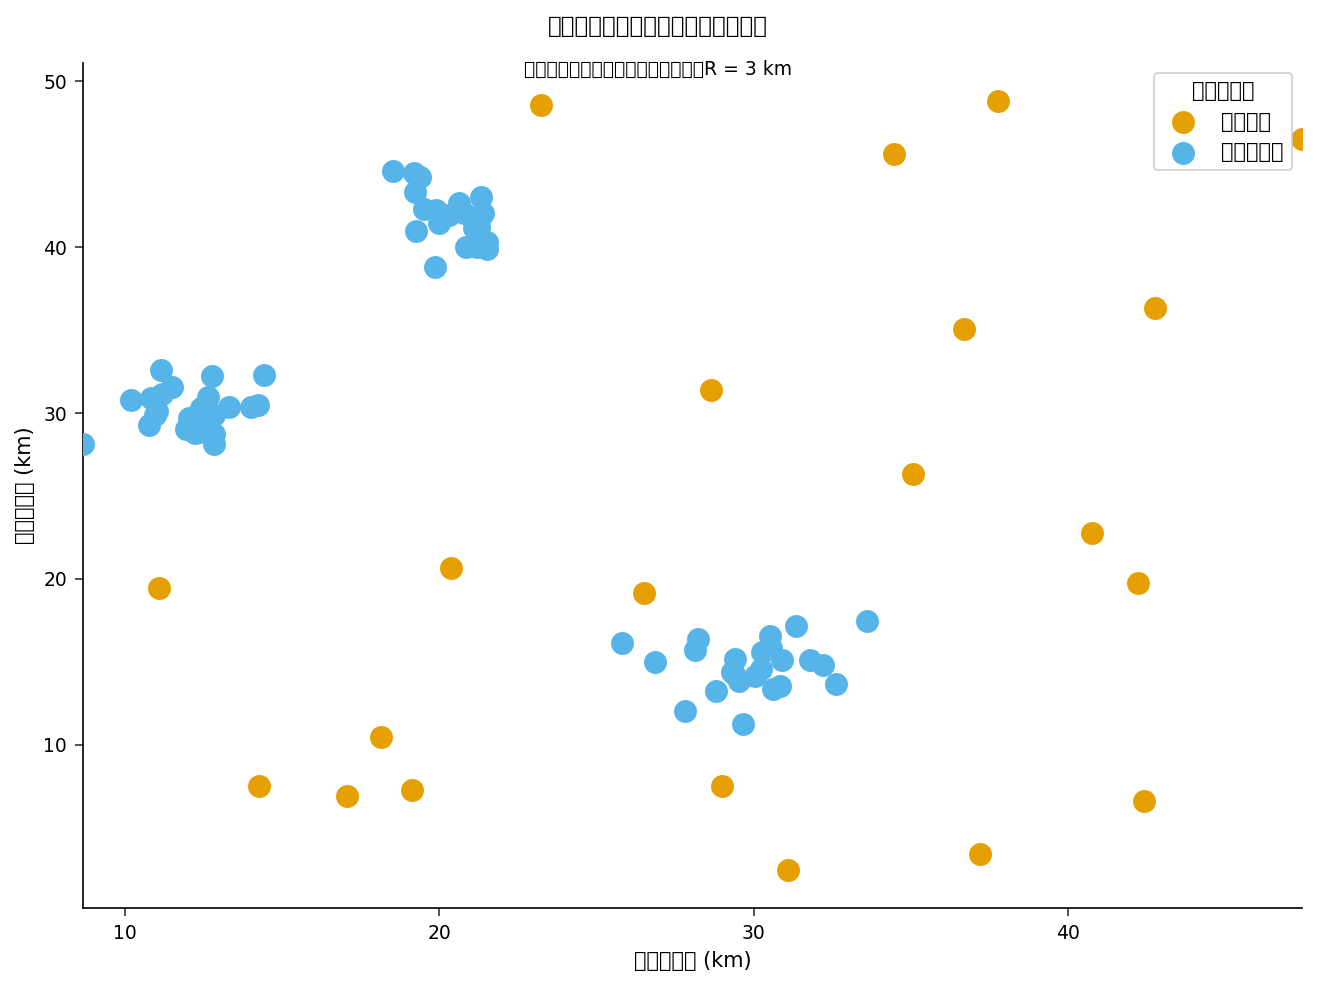

In [4]:
データ mapped;
   設定 join_out;
   長さ status $ 24;
   もし cluster <= 3 なら status = '高密度地区';
   他 status = '孤立地点';
実行;

表題 '回収されたサービス地区と孤立地点';
title2 '一様カーネル密度クラスタリング、R = 3 km';
処理 SGPLOT データ=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=cluster
                           MARKERATTRS=(size=10);
   XAXIS 見出='東方向距離 (km)';
   YAXIS 見出='北方向距離 (km)';
   keylegend / 表題='地点の状態';
実行;

表題;

## 結果の解釈

**MODECLUSが見出したこと。** `(x_km, y_km)`のみに基づいて、この手続きはデータに
組み込んだ3つの高密度サービス地区 -- UrbanCore(都市中心部)、Suburban(郊外)、
Industrial(工業地区)の塊り -- を、最大かつ最も密度の高い3クラスタ(24、24、21地点)
として回収する。領域全体から一様に抽出された散在する農村部の地点は疎な領域に落ち、
地区に吸収されるのではなく独自の1地点・2地点クラスタに分かれる。地図上では、
これらは3つのタイトな塊りから離れた点として現れる。この孤立地点の集合が業務上の
成果物であり、資本計画チーム向けの遠隔資産候補リストとなる。

**平滑化スキャンが重要な理由。** ノンパラメトリック密度クラスタリングにおいて、
単一の`R`が権威を持つことはない。`R=2.5 to 4 by 0.5`を走査することで、地区が
単一の帯域幅のアーティファクトではなく、平滑化レベルを通じて*安定している*ことを
確認できる。スキャンを通じてクラスタ数は23から18へとしか変化せず、その変化は
すべて散在する単独地点の数に起因する -- 3つの高密度地区は一貫して持続する。
このように構造が安定していれば、それは擁護可能な解であるが、もし数が激しく
振れていたなら、構造は脆弱であり投資判断を左右すべきではない。

**密度が結果を階層化する。** クラスタはモード密度の降順に番号付けされるため、
地区と孤立地点の境界は恣意的ではなく定量的である: 3つの地区はモード密度
0.008~0.009付近に位置する一方、すべての孤立地点はモード密度0.0004付近、
つまりおよそ20倍疎である。プランナーは密度の閾値を設定し、`join_out`の
`CLUSTER`列と`DENSITY`列から直接、孤立資産を読み取ることができる。

**実務上の利用。** `join_out`データセットは各地点に密度とクラスタラベルを
与え、これを下流の作業の起点とすることができる -- サービス地区ごとの
要員・予備品の規模決定、点検回線のルーティング、あるいは密度の高い工業クラスタ
(最も高い`peak_load_mw`、約6MW)でのグリッド強化の優先順位付けを行いつつ、
孤立した農村部の地点については頻度の低い個別保守をスケジュールする、といった
用途である。

*合成データに関する注記:* 座標と負荷は固定シード(`call streaminit(70531)`)で
シミュレートされているため、本ノートブックはオフラインで完全に再現可能である。
実際の事業者データでは、実測の地点座標と計測されたピーク負荷に置き換えることになる。
正確なクラスタ数は乱数の抽出と選択した半径に依存する。